# **Menghitung jarak antara data lama(buka tutup) masing masing 100 data dengan data baru 1 data menggunakan Dynamic Time Warping**

## **1.1 Suara Tutup**

In [35]:
import os
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 4)

In [36]:
DATASET_PATH = "dataset48k" 
train_path = os.path.join(DATASET_PATH, "train")

### **Visualisasi Suara Waveforms**

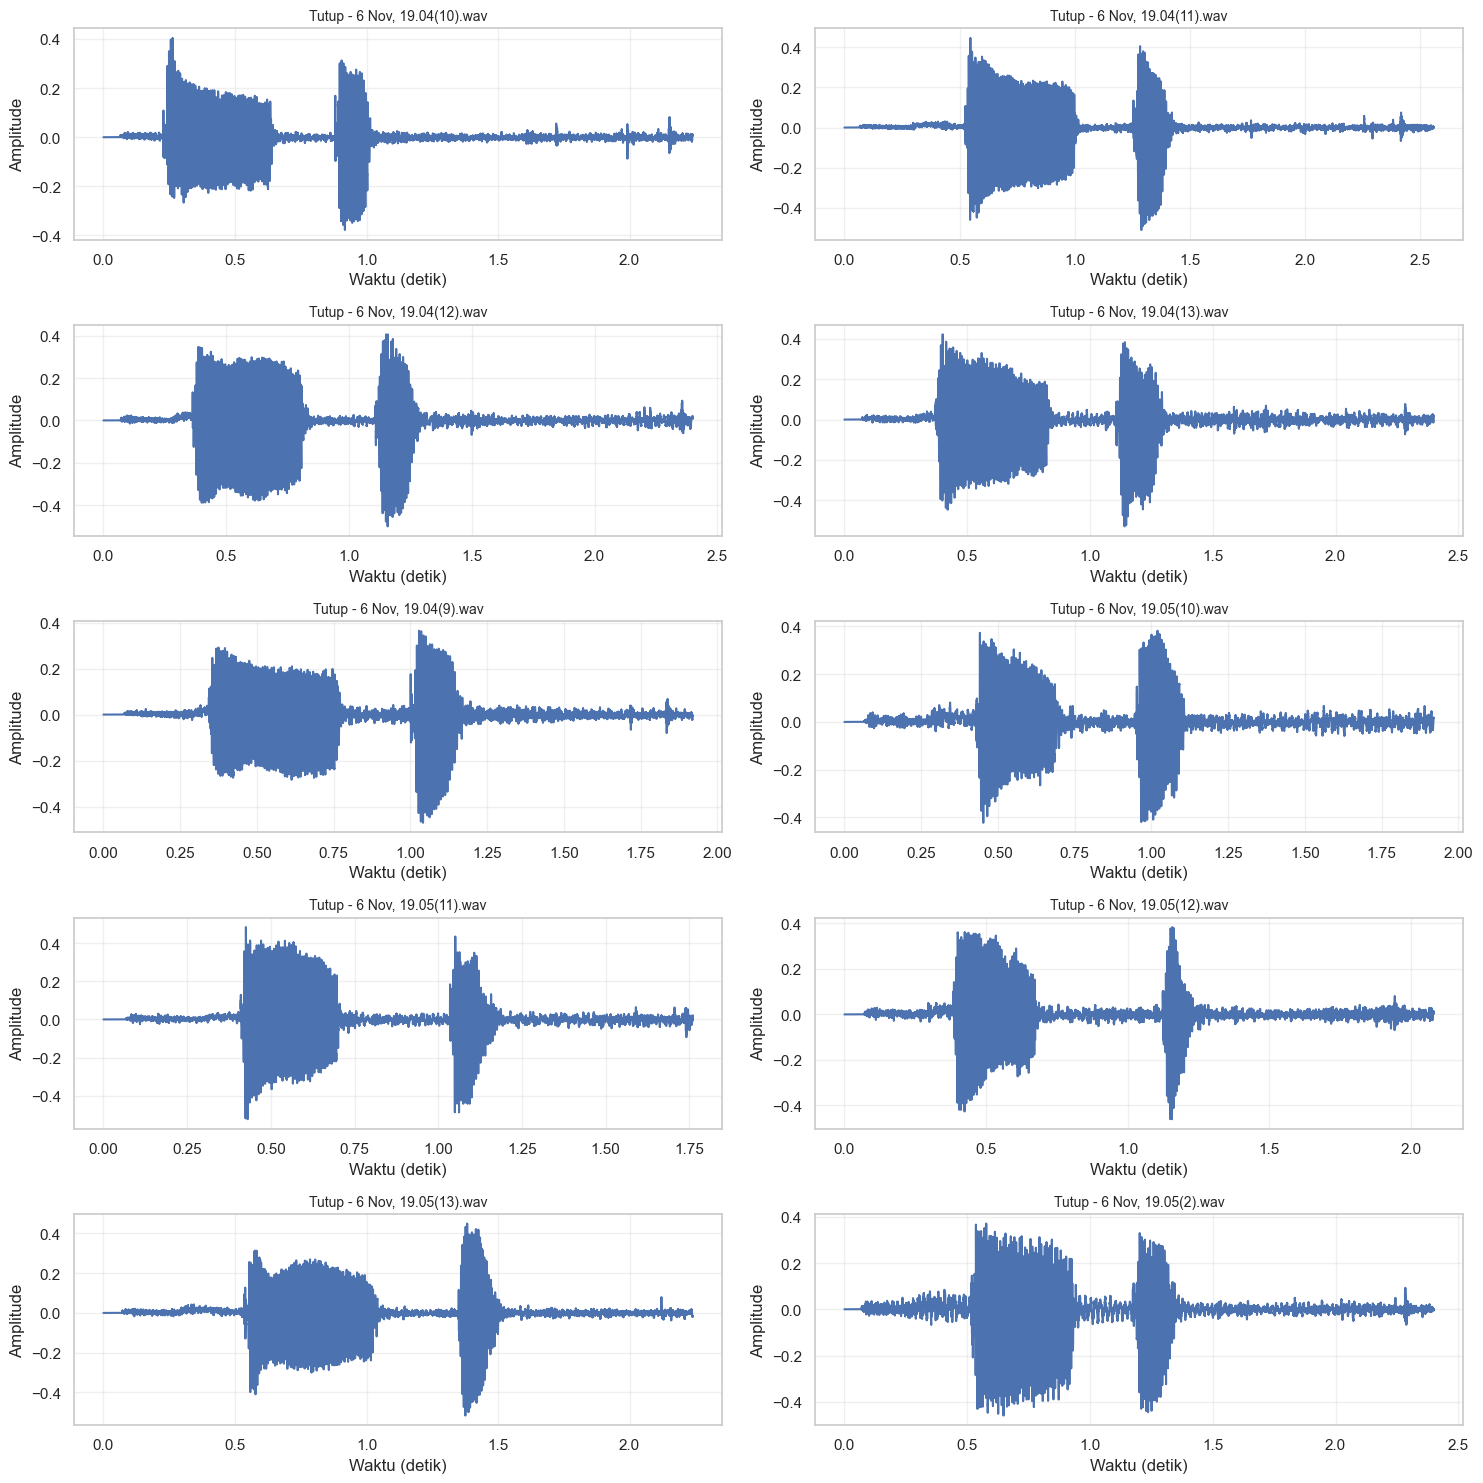

Menampilkan 10 file audio 'tutup'


In [37]:
def plot_all_tutup_timeseries(base_path, max_files=None):
    tutup_path = os.path.join(base_path, "tutup")
    tutup_files = os.listdir(tutup_path)
    
    if max_files:
        tutup_files = tutup_files[:max_files]
    
    n_files = len(tutup_files)
    

    cols = 2
    rows = (n_files + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, filename in enumerate(tutup_files):
        file_path = os.path.join(tutup_path, filename)
        
        # Load audio
        y, sr = librosa.load(file_path, sr=None)
        
        # Hitung time axis
        time = np.linspace(0, len(y)/sr, len(y))
        
        # Plot
        row = i // cols
        col = i % cols
        
        axes[row, col].plot(time, y)
        axes[row, col].set_title(f'Tutup - {filename}', fontsize=10)
        axes[row, col].set_xlabel('Waktu (detik)')
        axes[row, col].set_ylabel('Amplitude')
        axes[row, col].grid(True, alpha=0.3)
    
    for i in range(len(tutup_files), rows * cols):
        row = i // cols
        col = i % cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()
    
    print(f"Menampilkan {len(tutup_files)} file audio 'tutup'")

plot_all_tutup_timeseries(train_path, max_files=10)

### **Perhitungan Dynamic Time Warping**

In [38]:
import numpy as np
from dtaidistance import dtw
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# def extract_features_for_dtw(audio_path, feature_type='mfcc'):
#     y, sr = librosa.load(audio_path, sr=22050)
#     mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
#     mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
#     chroma = librosa.feature.chroma_stft(y=y, sr=sr)

#     mel_6_mean = np.mean(mel_spec_db[6, :])  
#     mel_6_std = np.std(mel_spec_db[6, :])    
#     mel_7_mean = np.mean(mel_spec_db[7, :])   
#     mel_7_std = np.std(mel_spec_db[7, :])    
#     chroma_0_mean = np.mean(chroma[0, :])    
    
#     from scipy.stats import skew
#     stat_skew = skew(y)
    
#     model_features = np.array([
#         mel_7_std,      
#         chroma_0_mean,
#         mel_6_std,      
#         stat_skew,      
#         mel_7_mean 
#     ])
    
#     return model_features

def extract_features_for_dtw(audio_path, n_mfcc=13):
    y, sr = librosa.load(audio_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    seq = mfcc[0, :]
    
    return seq



def calculate_dtw_distances(new_audio_path, train_path, max_files=100):
    try:
        # new_features = extract_features_for_dtw(new_audio_path, 'mfcc')
        new_features = extract_features_for_dtw(new_audio_path)
    except Exception as e:
        print(f"Errorrrrrrr")
        return None
    
    tutup_train_files = []
    train_labels = []
    
    tutup_path = os.path.join(train_path, "tutup")
    if os.path.exists(tutup_path):
        for file in os.listdir(tutup_path):
            if file.endswith(('.wav')):
                tutup_train_files.append(os.path.join(tutup_path, file))
                train_labels.append('tutup')
    
    if len(tutup_train_files) > max_files:
        indices = np.random.choice(len(tutup_train_files), max_files, replace=False)
        tutup_train_files = [tutup_train_files[i] for i in indices]
        train_labels = [train_labels[i] for i in indices]
    
    results = []
    
    for i, (train_file, label) in enumerate(zip(tutup_train_files, train_labels)):
        try:
            # Ekstrak fitur dari file training
            # train_features = extract_features_for_dtw(train_file, 'mfcc')
            train_features = extract_features_for_dtw(train_file)
            
            # Hitung jarak DTW
            dtw_distance = dtw.distance(new_features, train_features)
            
            results.append({
                'rank': i + 1,
                'filename': os.path.basename(train_file),
                'label': label,
                'dtw_distance': dtw_distance,
                'file_path': train_file
            })
            
                
        except Exception as e:
            print(f"  Error processing {train_file}: {e}")
            continue
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('dtw_distance').reset_index(drop=True)
    df_results['rank'] = range(1, len(df_results) + 1)
    
    return df_results

# Path audio baru
new_audio_path = "dataset48k/Tutup1(baru).wav"

# Hitung jarak DTW
dtw_results = calculate_dtw_distances(new_audio_path, train_path, max_files=100)

if dtw_results is not None:
    print(f"\n=== RANKING JARAK DTW (Top 20) ===")
    print(dtw_results.head(20).to_string(index=False))
    
    print(f"\n=== STATISTIK HASIL ===")
    print(f"Total file dianalisis: {len(dtw_results)}")
    print(f"Jarak minimum: {dtw_results['dtw_distance'].min():.4f}")
    print(f"Jarak maksimum: {dtw_results['dtw_distance'].max():.4f}")
    print(f"Jarak rata-rata: {dtw_results['dtw_distance'].mean():.4f}")
    


=== RANKING JARAK DTW (Top 20) ===
 rank              filename label  dtw_distance                                    file_path
    1           Tutup15.wav tutup    265.343527           dataset48k\train\tutup\Tutup15.wav
    2           Tutup14.wav tutup    276.004951           dataset48k\train\tutup\Tutup14.wav
    3           Tutup44.wav tutup    284.027816           dataset48k\train\tutup\Tutup44.wav
    4           Tutup38.wav tutup    314.968880           dataset48k\train\tutup\Tutup38.wav
    5           Tutup31.wav tutup    326.037383           dataset48k\train\tutup\Tutup31.wav
    6  6 Nov, 19.07​(7).wav tutup    335.279567  dataset48k\train\tutup\6 Nov, 19.07​(7).wav
    7  6 Nov, 19.08​(6).wav tutup    335.362672  dataset48k\train\tutup\6 Nov, 19.08​(6).wav
    8           Tutup25.wav tutup    347.615159           dataset48k\train\tutup\Tutup25.wav
    9  6 Nov, 19.08​(5).wav tutup    372.375543  dataset48k\train\tutup\6 Nov, 19.08​(5).wav
   10  6 Nov, 19.07​(6).wav tutup 

### **Perangkingan dan Perbandingan**

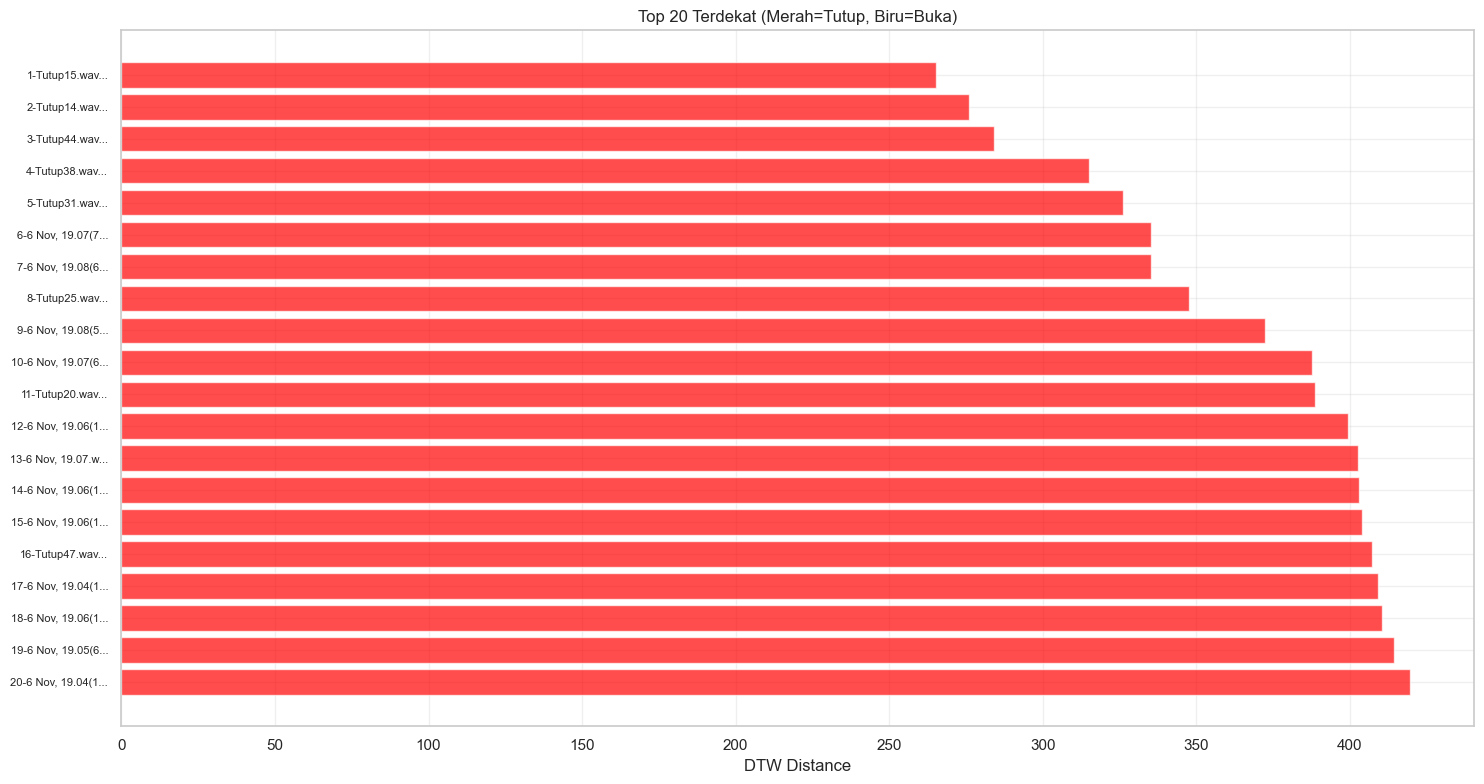


=== PERBANDINGAN WAVEFORM ===


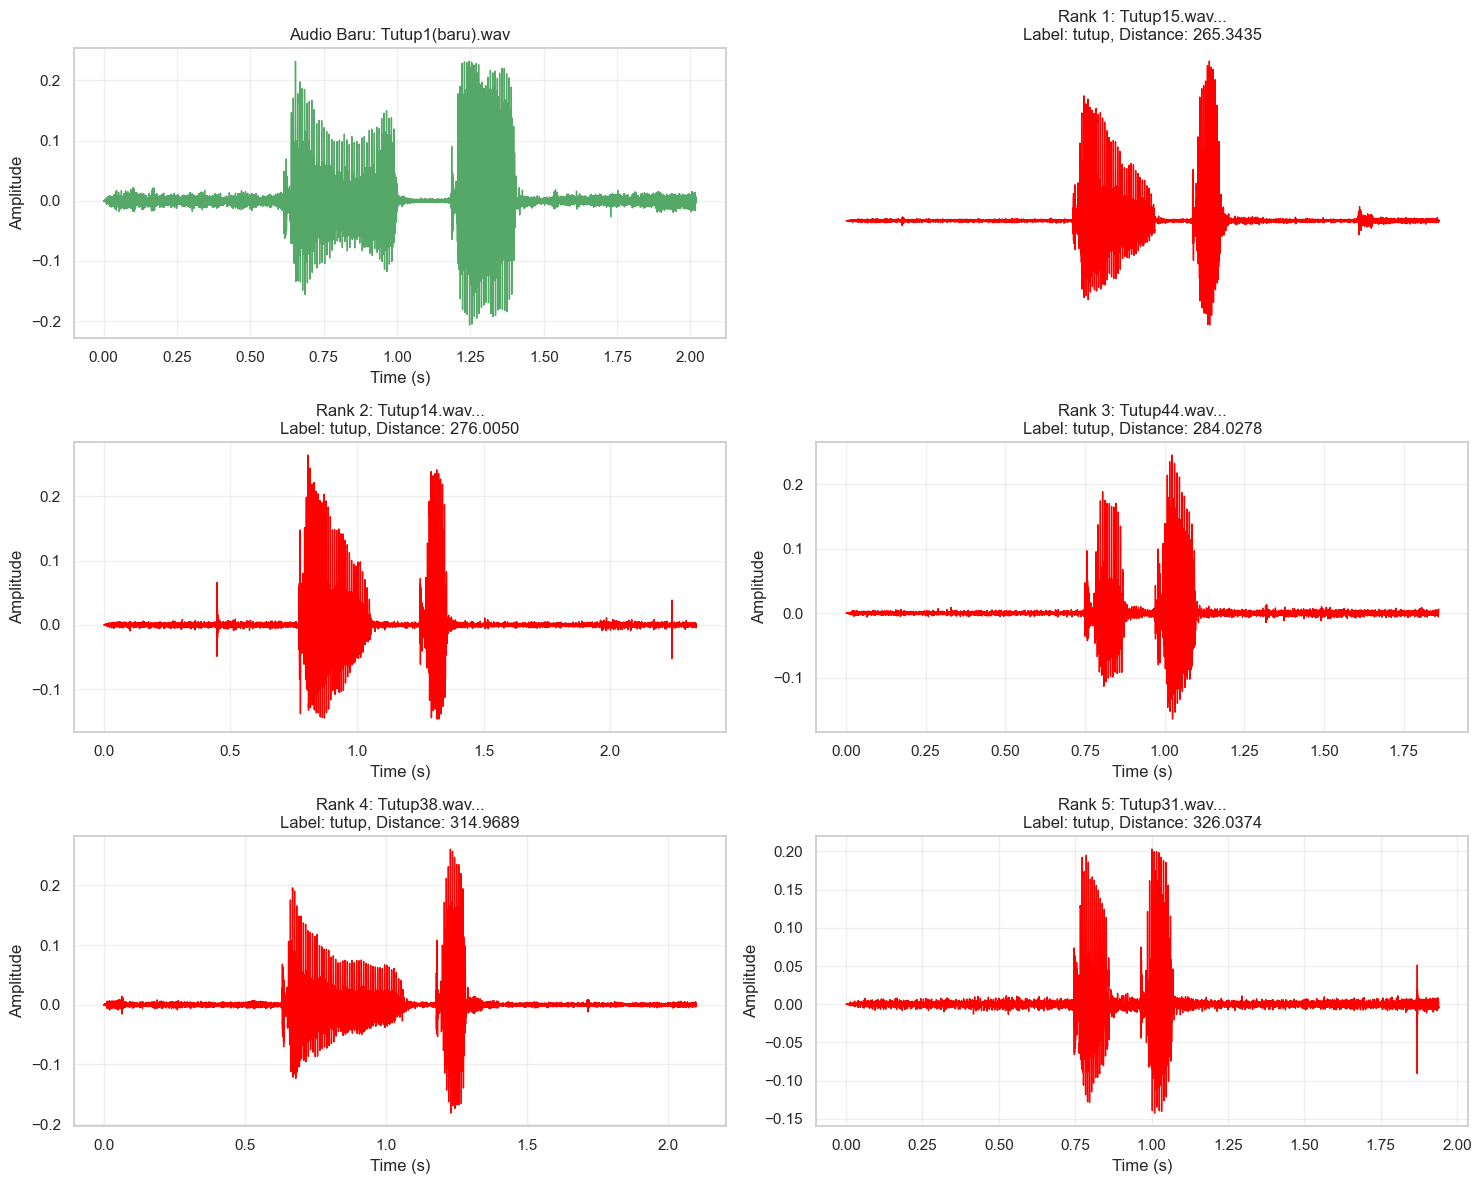


=== SEMUA RANKING DTW (1-100) ===
 rank              filename label  dtw_distance
    1           Tutup15.wav tutup    265.343527
    2           Tutup14.wav tutup    276.004951
    3           Tutup44.wav tutup    284.027816
    4           Tutup38.wav tutup    314.968880
    5           Tutup31.wav tutup    326.037383
    6  6 Nov, 19.07​(7).wav tutup    335.279567
    7  6 Nov, 19.08​(6).wav tutup    335.362672
    8           Tutup25.wav tutup    347.615159
    9  6 Nov, 19.08​(5).wav tutup    372.375543
   10  6 Nov, 19.07​(6).wav tutup    387.833421
   11           Tutup20.wav tutup    388.599898
   12 6 Nov, 19.06​(13).wav tutup    399.398134
   13     6 Nov, 19.07​.wav tutup    402.829169
   14 6 Nov, 19.06​(16).wav tutup    403.096635
   15 6 Nov, 19.06​(15).wav tutup    403.938040
   16           Tutup47.wav tutup    407.412048
   17 6 Nov, 19.04​(11).wav tutup    409.259880
   18 6 Nov, 19.06​(14).wav tutup    410.668593
   19  6 Nov, 19.05​(6).wav tutup    414.590149
   20

In [39]:
def visualize_dtw_results(dtw_results, new_audio_path):
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    
    # Top 20 ranking
    top_20 = dtw_results.head(20)
    colors = ['red' if label == 'tutup' else 'blue' for label in top_20['label']]
    
    ax.barh(range(len(top_20)), top_20['dtw_distance'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels([f"{row['rank']}-{row['filename'][:15]}..." 
                        for _, row in top_20.iterrows()], fontsize=8)
    ax.set_xlabel('DTW Distance')
    ax.set_title('Top 20 Terdekat (Merah=Tutup, Biru=Buka)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== PERBANDINGAN WAVEFORM ===")
    plot_waveform_comparison(new_audio_path, dtw_results.head(5))

def plot_waveform_comparison(new_audio_path, top_matches):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    # Audio baru
    y_new, sr_new = librosa.load(new_audio_path, sr=22050)
    time_new = np.linspace(0, len(y_new)/sr_new, len(y_new))
    
    axes[0, 0].plot(time_new, y_new, 'g-', linewidth=1)
    axes[0, 0].set_title(f'Audio Baru: {os.path.basename(new_audio_path)}')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True, alpha=0.3)
    
    for i, (_, row) in enumerate(top_matches.iterrows()):
        if i >= 5:
            break
            
        try:
            y_match, sr_match = librosa.load(row['file_path'], sr=22050)
            time_match = np.linspace(0, len(y_match)/sr_match, len(y_match))
            
            row_idx = (i + 1) // 2
            col_idx = (i + 1) % 2
            
            if row_idx < 3:
                color = 'red' if row['label'] == 'tutup' else 'blue'
                axes[row_idx, col_idx].plot(time_match, y_match, color=color, linewidth=1)
                axes[row_idx, col_idx].set_title(f'Rank {row["rank"]}: {row["filename"][:20]}...\nLabel: {row["label"]}, Distance: {row["dtw_distance"]:.4f}')
                axes[row_idx, col_idx].set_xlabel('Time (s)')
                axes[row_idx, col_idx].set_ylabel('Amplitude')
                axes[row_idx, col_idx].grid(True, alpha=0.3)
        except Exception as e:
            print(f"Error loading {row['filename']}: {e}")
            continue
    
    axes[0, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

if dtw_results is not None:
    visualize_dtw_results(dtw_results, new_audio_path)
    
    print(f"\n=== SEMUA RANKING DTW (1-{len(dtw_results)}) ===")
    print(dtw_results[['rank', 'filename', 'label', 'dtw_distance']].to_string(index=False))

## **1.2 Suara Buka**

In [40]:
import os
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 4)

In [41]:
DATASET_PATH = "dataset48k" 
train_path = os.path.join(DATASET_PATH, "train")

### **Visualisasi Suara Waveforms**

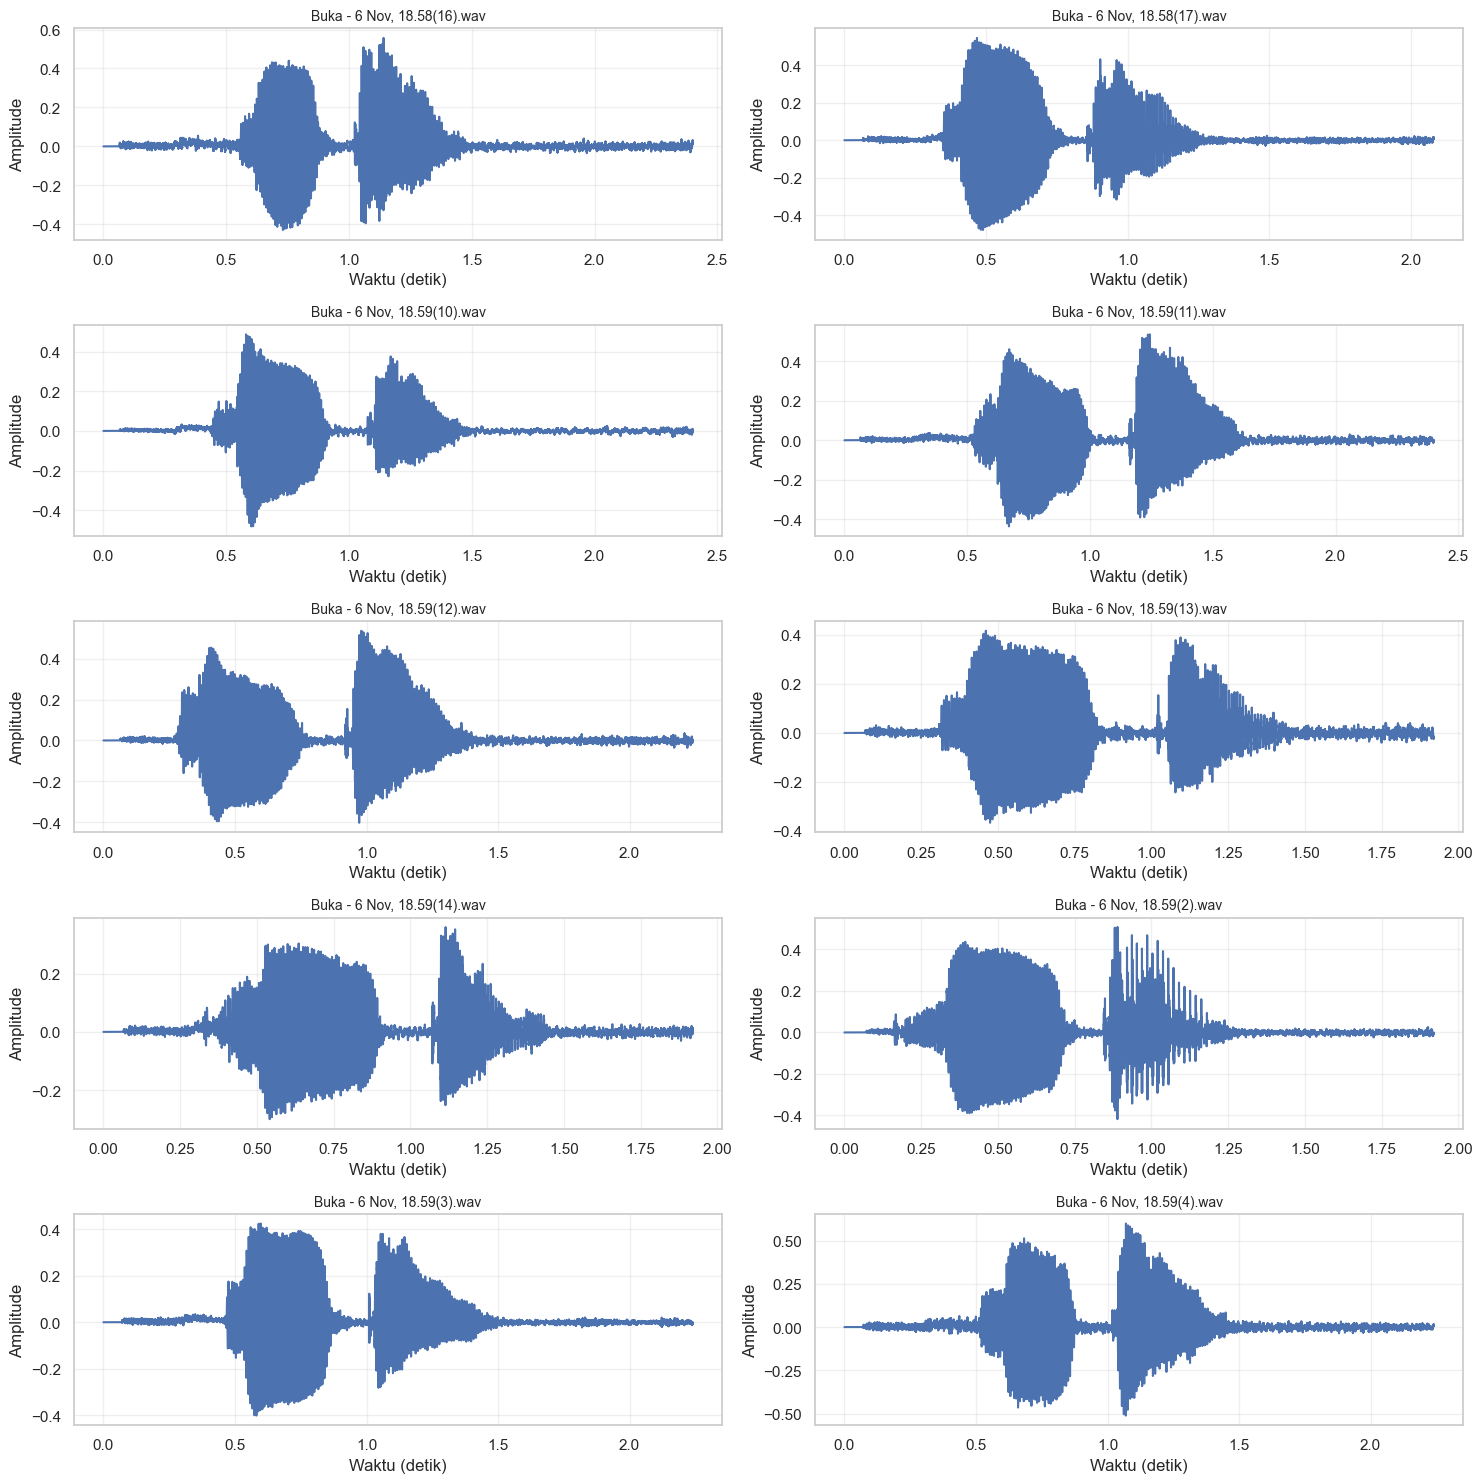

Menampilkan 10 file audio 'buka'


In [42]:
def plot_all_tutup_timeseries(base_path, max_files=None):
    tutup_path = os.path.join(base_path, "buka")
    tutup_files = os.listdir(tutup_path)
    
    if max_files:
        tutup_files = tutup_files[:max_files]
    
    n_files = len(tutup_files)
    

    cols = 2
    rows = (n_files + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, filename in enumerate(tutup_files):
        file_path = os.path.join(tutup_path, filename)
        
        # Load audio
        y, sr = librosa.load(file_path, sr=None)
        
        # Hitung time axis
        time = np.linspace(0, len(y)/sr, len(y))
        
        # Plot
        row = i // cols
        col = i % cols
        
        axes[row, col].plot(time, y)
        axes[row, col].set_title(f'Buka - {filename}', fontsize=10)
        axes[row, col].set_xlabel('Waktu (detik)')
        axes[row, col].set_ylabel('Amplitude')
        axes[row, col].grid(True, alpha=0.3)
    
    for i in range(len(tutup_files), rows * cols):
        row = i // cols
        col = i % cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()
    
    print(f"Menampilkan {len(tutup_files)} file audio 'buka'")

plot_all_tutup_timeseries(train_path, max_files=10)

### **Perhitungan Dynamic Time Warping**

In [43]:
import numpy as np
from dtaidistance import dtw
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# def extract_features_for_dtw(audio_path, feature_type='mfcc'):
#     y, sr = librosa.load(audio_path, sr=22050)
#     mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
#     mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
#     chroma = librosa.feature.chroma_stft(y=y, sr=sr)

#     mel_6_mean = np.mean(mel_spec_db[6, :])  
#     mel_6_std = np.std(mel_spec_db[6, :])    
#     mel_7_mean = np.mean(mel_spec_db[7, :])   
#     mel_7_std = np.std(mel_spec_db[7, :])    
#     chroma_0_mean = np.mean(chroma[0, :])    
    
#     from scipy.stats import skew
#     stat_skew = skew(y)
    
#     model_features = np.array([
#         mel_7_std,      
#         chroma_0_mean,
#         mel_6_std,      
#         stat_skew,      
#         mel_7_mean 
#     ])
    
#     return model_features

def extract_features_for_dtw(audio_path, n_mfcc=13):
    y, sr = librosa.load(audio_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    seq = mfcc[0, :]
    
    return seq



def calculate_dtw_distances(new_audio_path, train_path, max_files=100):
    try:
        # new_features = extract_features_for_dtw(new_audio_path, 'mfcc')
        new_features = extract_features_for_dtw(new_audio_path)
    except Exception as e:
        print(f"Errorrrrrrr")
        return None
    
    tutup_train_files = []
    train_labels = []
    
    tutup_path = os.path.join(train_path, "buka")
    if os.path.exists(tutup_path):
        for file in os.listdir(tutup_path):
            if file.endswith(('.wav')):
                tutup_train_files.append(os.path.join(tutup_path, file))
                train_labels.append('buka')
    
    if len(tutup_train_files) > max_files:
        indices = np.random.choice(len(tutup_train_files), max_files, replace=False)
        tutup_train_files = [tutup_train_files[i] for i in indices]
        train_labels = [train_labels[i] for i in indices]
    
    results = []
    
    for i, (train_file, label) in enumerate(zip(tutup_train_files, train_labels)):
        try:
            # Ekstrak fitur dari file training
            # train_features = extract_features_for_dtw(train_file, 'mfcc')
            train_features = extract_features_for_dtw(train_file)
            
            # Hitung jarak DTW
            dtw_distance = dtw.distance(new_features, train_features)
            
            results.append({
                'rank': i + 1,
                'filename': os.path.basename(train_file),
                'label': label,
                'dtw_distance': dtw_distance,
                'file_path': train_file
            })
            
                
        except Exception as e:
            print(f"  Error processing {train_file}: {e}")
            continue
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('dtw_distance').reset_index(drop=True)
    df_results['rank'] = range(1, len(df_results) + 1)
    
    return df_results

# Path audio baru
new_audio_path = "dataset48k/buka1(baru).wav"

# Hitung jarak DTW
dtw_results = calculate_dtw_distances(new_audio_path, train_path, max_files=100)

if dtw_results is not None:
    print(f"\n=== RANKING JARAK DTW (Top 20) ===")
    print(dtw_results.head(20).to_string(index=False))
    
    print(f"\n=== STATISTIK HASIL ===")
    print(f"Total file dianalisis: {len(dtw_results)}")
    print(f"Jarak minimum: {dtw_results['dtw_distance'].min():.4f}")
    print(f"Jarak maksimum: {dtw_results['dtw_distance'].max():.4f}")
    print(f"Jarak rata-rata: {dtw_results['dtw_distance'].mean():.4f}")
    


=== RANKING JARAK DTW (Top 20) ===
 rank              filename label  dtw_distance                                   file_path
    1  6 Nov, 19.00​(7).wav  buka    153.579828  dataset48k\train\buka\6 Nov, 19.00​(7).wav
    2  6 Nov, 19.00​(8).wav  buka    166.499162  dataset48k\train\buka\6 Nov, 19.00​(8).wav
    3     6 Nov, 19.01​.wav  buka    174.230570     dataset48k\train\buka\6 Nov, 19.01​.wav
    4  6 Nov, 19.00​(9).wav  buka    175.591258  dataset48k\train\buka\6 Nov, 19.00​(9).wav
    5 6 Nov, 19.00​(13).wav  buka    185.264872 dataset48k\train\buka\6 Nov, 19.00​(13).wav
    6 6 Nov, 18.59​(13).wav  buka    185.414561 dataset48k\train\buka\6 Nov, 18.59​(13).wav
    7 6 Nov, 19.01​(17).wav  buka    187.480838 dataset48k\train\buka\6 Nov, 19.01​(17).wav
    8  6 Nov, 19.01​(5).wav  buka    190.082019  dataset48k\train\buka\6 Nov, 19.01​(5).wav
    9 6 Nov, 18.58​(17).wav  buka    193.261965 dataset48k\train\buka\6 Nov, 18.58​(17).wav
   10 6 Nov, 18.59​(14).wav  buka    200.319

### **Perangkingan dan Perbandingan**

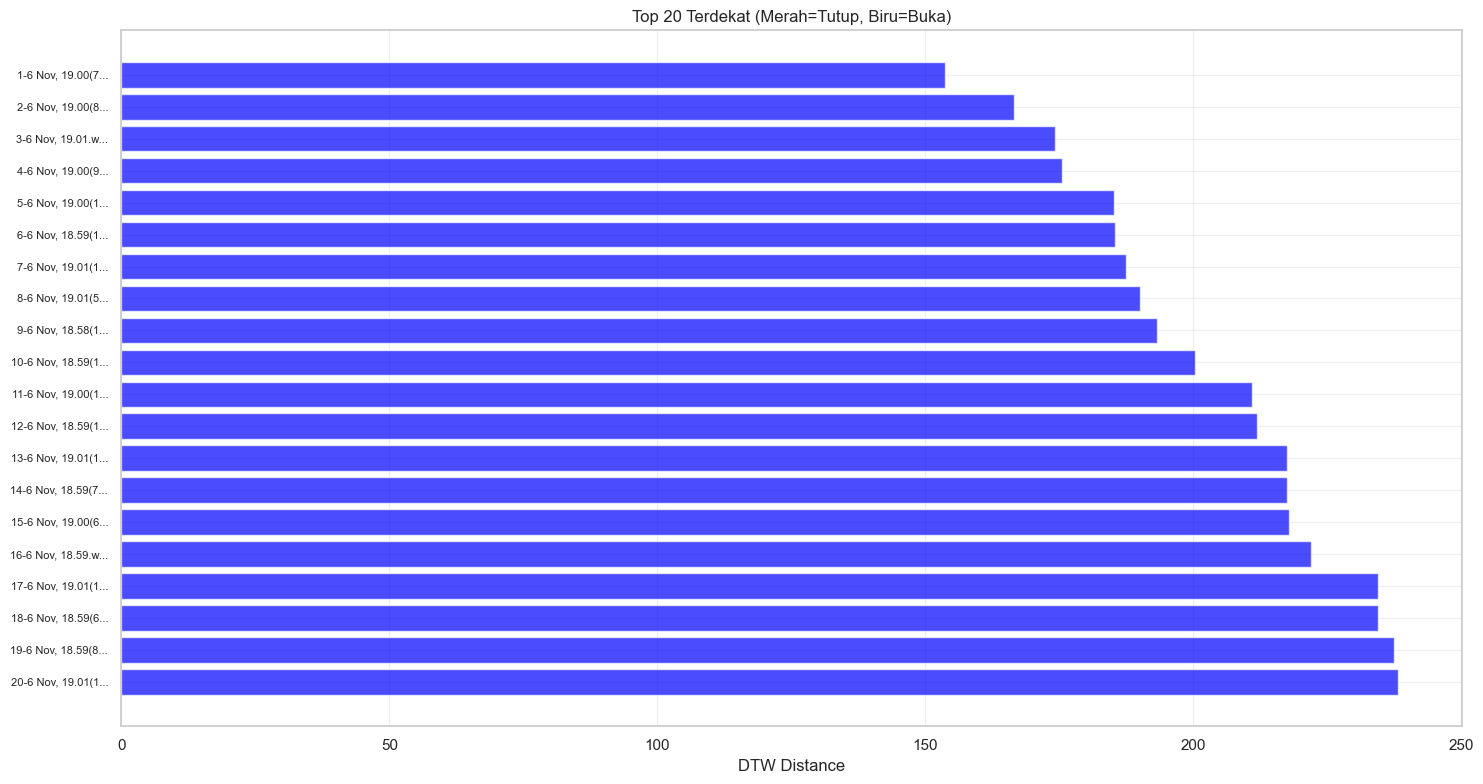


=== PERBANDINGAN WAVEFORM ===


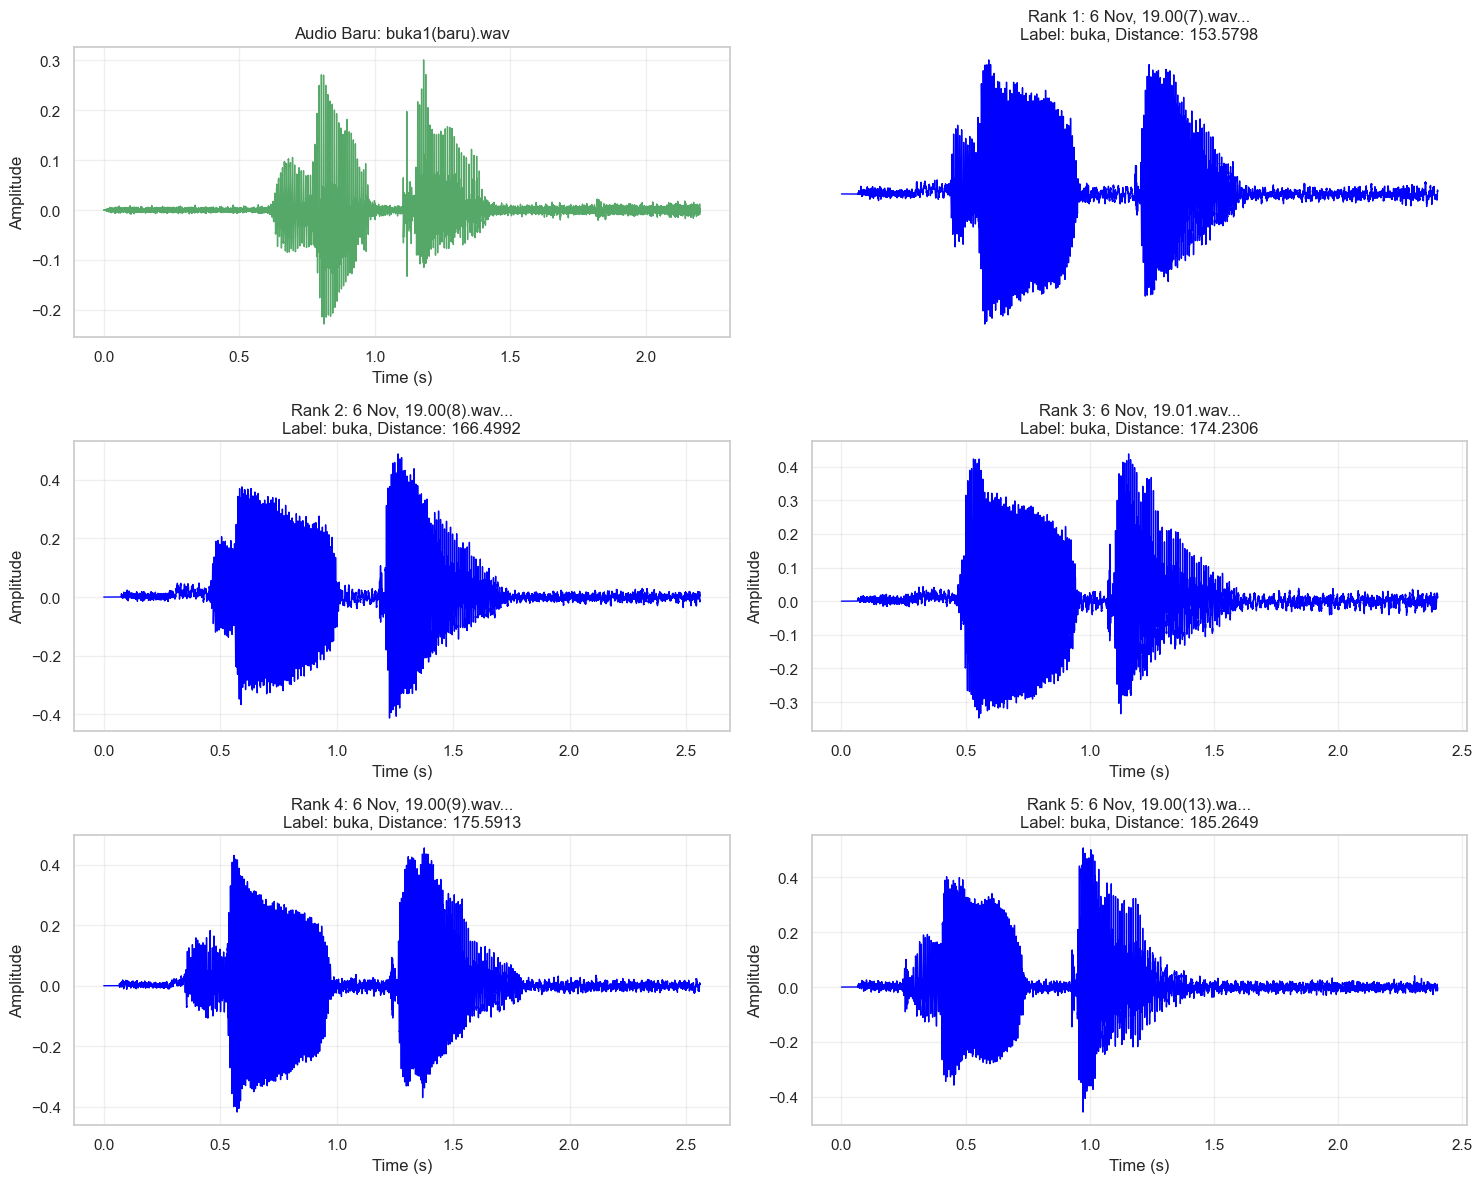


=== SEMUA RANKING DTW (1-100) ===
 rank              filename label  dtw_distance
    1  6 Nov, 19.00​(7).wav  buka    153.579828
    2  6 Nov, 19.00​(8).wav  buka    166.499162
    3     6 Nov, 19.01​.wav  buka    174.230570
    4  6 Nov, 19.00​(9).wav  buka    175.591258
    5 6 Nov, 19.00​(13).wav  buka    185.264872
    6 6 Nov, 18.59​(13).wav  buka    185.414561
    7 6 Nov, 19.01​(17).wav  buka    187.480838
    8  6 Nov, 19.01​(5).wav  buka    190.082019
    9 6 Nov, 18.58​(17).wav  buka    193.261965
   10 6 Nov, 18.59​(14).wav  buka    200.319067
   11 6 Nov, 19.00​(10).wav  buka    211.001956
   12 6 Nov, 18.59​(11).wav  buka    211.888206
   13 6 Nov, 19.01​(10).wav  buka    217.457910
   14  6 Nov, 18.59​(7).wav  buka    217.542363
   15  6 Nov, 19.00​(6).wav  buka    217.889946
   16     6 Nov, 18.59​.wav  buka    221.884282
   17 6 Nov, 19.01​(11).wav  buka    234.538868
   18  6 Nov, 18.59​(6).wav  buka    234.551967
   19  6 Nov, 18.59​(8).wav  buka    237.356303
   20

In [44]:
def visualize_dtw_results(dtw_results, new_audio_path):
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    
    # Top 20 ranking
    top_20 = dtw_results.head(20)
    colors = ['red' if label == 'tutup' else 'blue' for label in top_20['label']]
    
    ax.barh(range(len(top_20)), top_20['dtw_distance'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels([f"{row['rank']}-{row['filename'][:15]}..." 
                        for _, row in top_20.iterrows()], fontsize=8)
    ax.set_xlabel('DTW Distance')
    ax.set_title('Top 20 Terdekat (Merah=Tutup, Biru=Buka)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Waveform comparison
    print("\n=== PERBANDINGAN WAVEFORM ===")
    plot_waveform_comparison(new_audio_path, dtw_results.head(5))

def plot_waveform_comparison(new_audio_path, top_matches):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    # Audio baru
    y_new, sr_new = librosa.load(new_audio_path, sr=22050)
    time_new = np.linspace(0, len(y_new)/sr_new, len(y_new))
    
    axes[0, 0].plot(time_new, y_new, 'g-', linewidth=1)
    axes[0, 0].set_title(f'Audio Baru: {os.path.basename(new_audio_path)}')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True, alpha=0.3)
    
    for i, (_, row) in enumerate(top_matches.iterrows()):
        if i >= 5:
            break
            
        try:
            y_match, sr_match = librosa.load(row['file_path'], sr=22050)
            time_match = np.linspace(0, len(y_match)/sr_match, len(y_match))
            
            row_idx = (i + 1) // 2
            col_idx = (i + 1) % 2
            
            if row_idx < 3:
                color = 'red' if row['label'] == 'tutup' else 'blue'
                axes[row_idx, col_idx].plot(time_match, y_match, color=color, linewidth=1)
                axes[row_idx, col_idx].set_title(f'Rank {row["rank"]}: {row["filename"][:20]}...\nLabel: {row["label"]}, Distance: {row["dtw_distance"]:.4f}')
                axes[row_idx, col_idx].set_xlabel('Time (s)')
                axes[row_idx, col_idx].set_ylabel('Amplitude')
                axes[row_idx, col_idx].grid(True, alpha=0.3)
        except Exception as e:
            print(f"Error loading {row['filename']}: {e}")
            continue
    
    axes[0, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

if dtw_results is not None:
    visualize_dtw_results(dtw_results, new_audio_path)
    
    print(f"\n=== SEMUA RANKING DTW (1-{len(dtw_results)}) ===")
    print(dtw_results[['rank', 'filename', 'label', 'dtw_distance']].to_string(index=False))

## **1.3 Clustering**

CLUSTERING SUARA BUKA DAN TUTUP
Total file: 100
  - Buka : 50
  - Tutup: 50


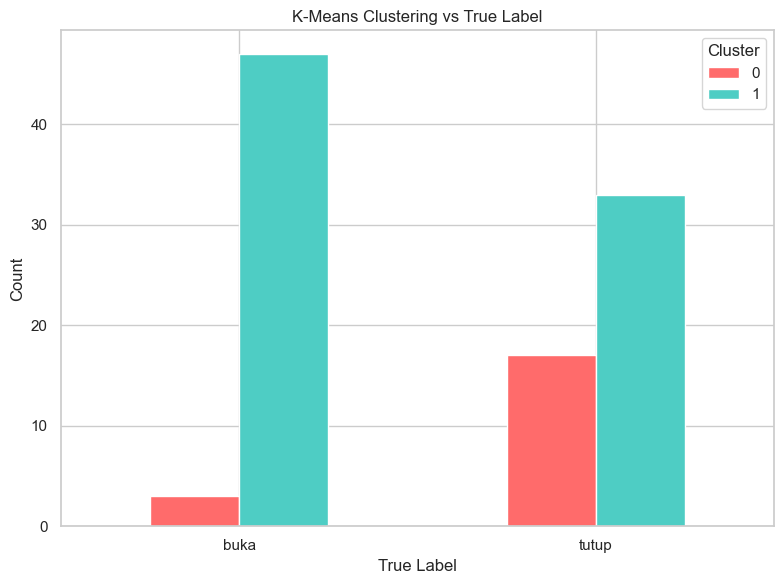

=== EVALUASI CLUSTERING (K-Means) ===
  Adjusted Rand Index : 0.0724
  Normalized Mutual Info : 0.1113

=== HASIL CLUSTERING ===
             filename true_label  kmeans_cluster
6 Nov, 18.58​(16).wav       buka               0
6 Nov, 18.58​(17).wav       buka               1
6 Nov, 18.59​(10).wav       buka               1
6 Nov, 18.59​(11).wav       buka               1
6 Nov, 18.59​(12).wav       buka               1
6 Nov, 18.59​(13).wav       buka               1
6 Nov, 18.59​(14).wav       buka               1
 6 Nov, 18.59​(2).wav       buka               1
 6 Nov, 18.59​(3).wav       buka               1
 6 Nov, 18.59​(4).wav       buka               0
 6 Nov, 18.59​(5).wav       buka               1
 6 Nov, 18.59​(6).wav       buka               1
 6 Nov, 18.59​(7).wav       buka               1
 6 Nov, 18.59​(8).wav       buka               1
 6 Nov, 18.59​(9).wav       buka               1
    6 Nov, 18.59​.wav       buka               1
6 Nov, 19.00​(10).wav       buka      

In [45]:
def compute_dtw_distance_matrix(audio_files, labels):
    n = len(audio_files)
    distance_matrix = np.zeros((n, n))
    features_list = []

    for i, file_path in enumerate(audio_files):
        try:
            features = extract_features_for_dtw(file_path)
            features_list.append(features)
        except Exception as e:
            print(f"Error: {file_path} - {e}")
            features_list.append(None)
    
    for i in range(n):
        for j in range(i+1, n):
            if features_list[i] is not None and features_list[j] is not None:
                dist = dtw.distance(features_list[i], features_list[j])
                distance_matrix[i, j] = dist
                distance_matrix[j, i] = dist
    
    return distance_matrix, features_list

from sklearn.cluster import KMeans

def perform_kmeans_clustering(distance_matrix, labels, filenames, n_clusters=2):
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(distance_matrix)
    
    df_clustering = pd.DataFrame({
        'filename': filenames,
        'true_label': labels,
        'kmeans_cluster': kmeans_labels
    })
    
    return df_clustering, kmeans_labels

def visualize_kmeans_clustering(df_clustering):
    comparison_kmeans = pd.crosstab(df_clustering['true_label'],
                                     df_clustering['kmeans_cluster'])
    
    ax = comparison_kmeans.plot(kind='bar',
                                figsize=(8, 6),
                                color=['#FF6B6B', '#4ECDC4'])
    
    plt.title('K-Means Clustering vs True Label', fontsize=12)
    plt.xlabel('True Label')
    plt.ylabel('Count')
    plt.legend(title='Cluster')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

def calculate_kmeans_accuracy(df_clustering):
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    
    true_numeric = df_clustering['true_label'].map({'buka': 0, 'tutup': 1}).values
    
    kmeans_ari = adjusted_rand_score(true_numeric, df_clustering['kmeans_cluster'])
    kmeans_nmi = normalized_mutual_info_score(true_numeric, df_clustering['kmeans_cluster'])
    
    print("=== EVALUASI CLUSTERING (K-Means) ===")
    print(f"  Adjusted Rand Index : {kmeans_ari:.4f}")
    print(f"  Normalized Mutual Info : {kmeans_nmi:.4f}")
    
    return kmeans_ari, kmeans_nmi

print("=" * 50)
print("CLUSTERING SUARA BUKA DAN TUTUP")
print("=" * 50)

all_files = []
all_labels = []
all_filenames = []

buka_path = os.path.join(train_path, "buka")
tutup_path = os.path.join(train_path, "tutup")

if os.path.exists(buka_path):
    buka_files = [f for f in os.listdir(buka_path) if f.endswith('.wav')][:50]
    for f in buka_files:
        all_files.append(os.path.join(buka_path, f))
        all_labels.append('buka')
        all_filenames.append(f)

if os.path.exists(tutup_path):
    tutup_files = [f for f in os.listdir(tutup_path) if f.endswith('.wav')][:50]
    for f in tutup_files:
        all_files.append(os.path.join(tutup_path, f))
        all_labels.append('tutup')
        all_filenames.append(f)

print(f"Total file: {len(all_files)}")
print(f"  - Buka : {all_labels.count('buka')}")
print(f"  - Tutup: {all_labels.count('tutup')}")

distance_matrix, features_list = compute_dtw_distance_matrix(all_files, all_labels)

df_clustering, kmeans_labels = perform_kmeans_clustering(
    distance_matrix, all_labels, all_filenames, n_clusters=2
)

visualize_kmeans_clustering(df_clustering)
calculate_kmeans_accuracy(df_clustering)

print("\n=== HASIL CLUSTERING ===")
print(df_clustering.to_string(index=False))



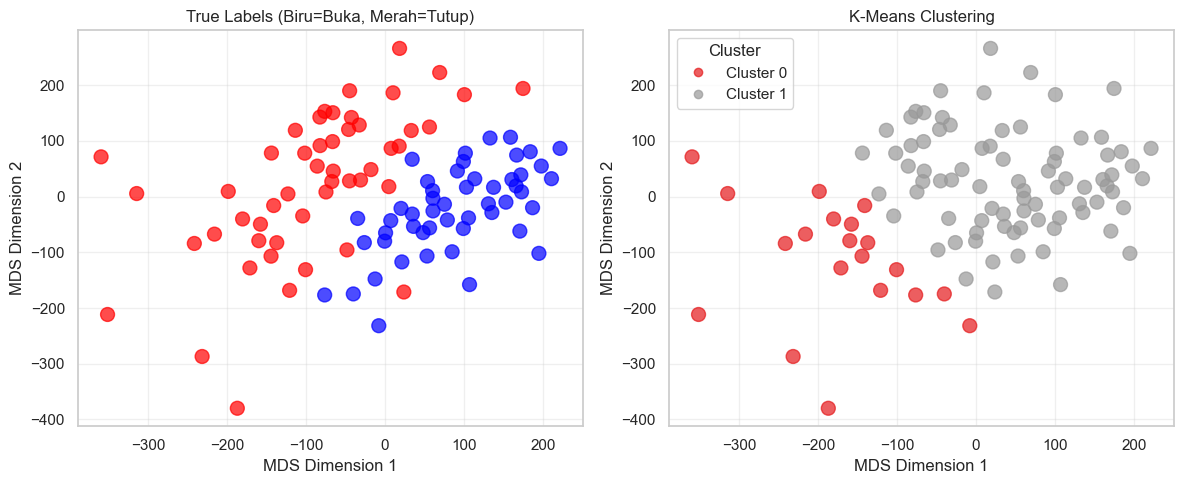

In [46]:
from sklearn.manifold import MDS

def visualize_mds_kmeans(distance_matrix, df_clustering):
    mds = MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=42,
        normalized_stress='auto'
    )
    coords = mds.fit_transform(distance_matrix)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # True Labels
    colors_true = ['blue' if l == 'buka' else 'red'
                   for l in df_clustering['true_label']]
    axes[0].scatter(coords[:, 0], coords[:, 1],
                    c=colors_true, alpha=0.7, s=100)
    axes[0].set_title('True Labels (Biru=Buka, Merah=Tutup)', fontsize=12)
    axes[0].set_xlabel('MDS Dimension 1')
    axes[0].set_ylabel('MDS Dimension 2')
    axes[0].grid(True, alpha=0.3)

    # K-Means Clusters
    sc = axes[1].scatter(coords[:, 0], coords[:, 1],
                         c=df_clustering['kmeans_cluster'],
                         cmap='Set1', alpha=0.7, s=100)
    axes[1].set_title('K-Means Clustering', fontsize=12)
    axes[1].set_xlabel('MDS Dimension 1')
    axes[1].set_ylabel('MDS Dimension 2')
    axes[1].grid(True, alpha=0.3)

    handles, _ = sc.legend_elements()
    axes[1].legend(handles, [f'Cluster {i}' for i in range(len(handles))],
                   title='Cluster')

    plt.tight_layout()
    plt.show()
    
visualize_mds_kmeans(distance_matrix, df_clustering)
